# Первичный анализ данных
https://www.kaggle.com/datasets/uciml/glass
около 10 кб, 214 строк по 10 числовых признаков, пропусков нет

In [15]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb
import time
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
df = pd.read_csv('glass.csv')
df.shape

(214, 10)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [17]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [18]:
df['Type'].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

распределение классов не сбалансировано (это проблема)

<Axes: >

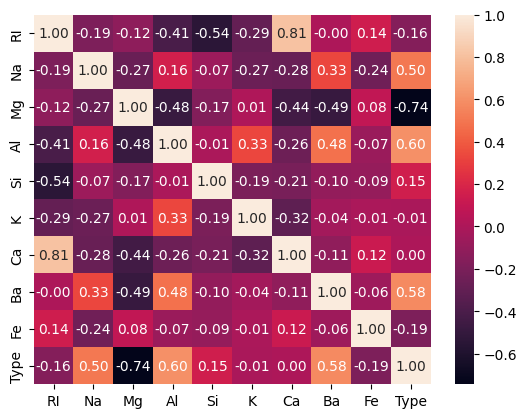

In [19]:
sb.heatmap(df.select_dtypes('number').corr(),annot=True,fmt=".2f")

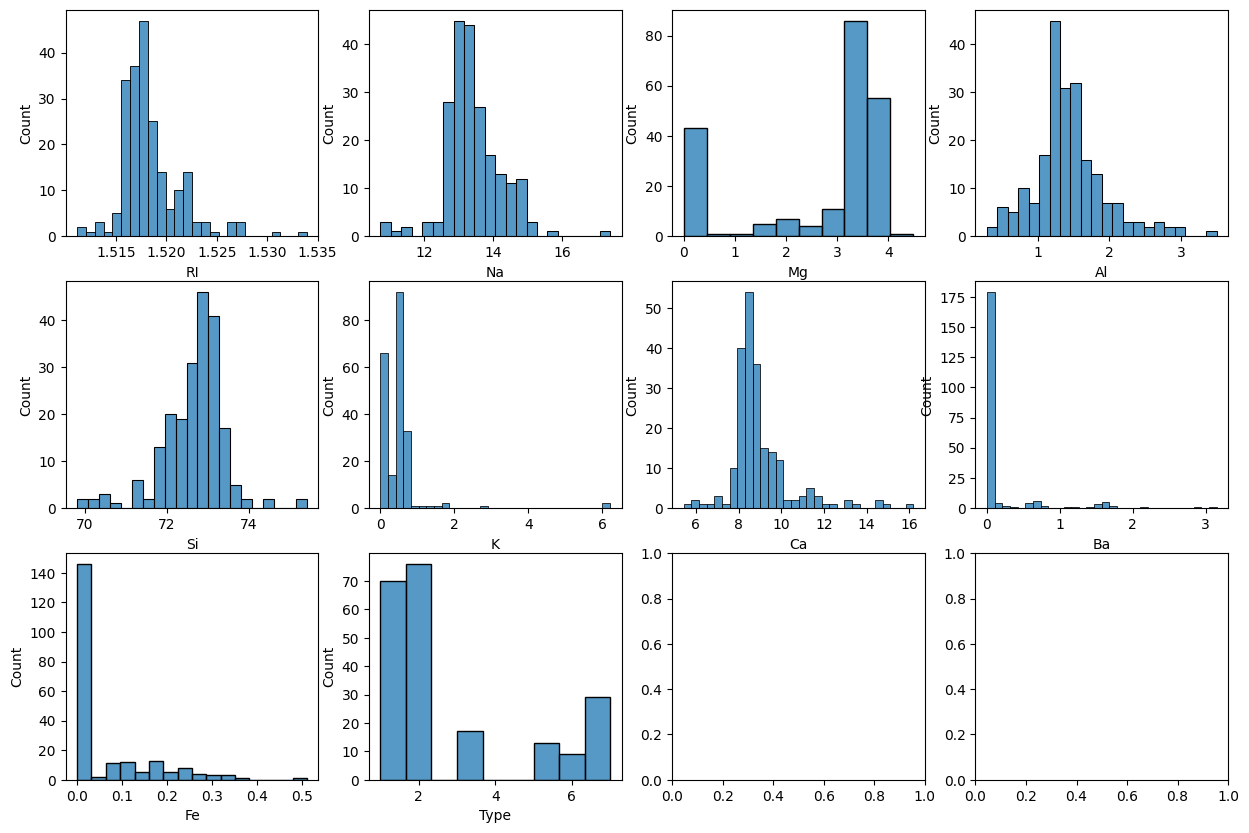

In [20]:


fig, axes = plt.subplots(3, 4, figsize=(15, 10))

for i, el in enumerate(df.columns.array):
    sb.histplot(data=df, x=el, ax=axes[i//4, i%4])


нормализация через MinMaxScaler

In [21]:
df_scaled = df.copy()
el= ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
df_scaled[el]=MinMaxScaler().fit_transform(df[el])
df_scaled

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,0.432836,0.437594,1.000000,0.252336,0.351786,0.009662,0.308550,0.000000,0.0,1
1,0.283582,0.475188,0.801782,0.333333,0.521429,0.077295,0.223048,0.000000,0.0,1
2,0.220808,0.421053,0.790646,0.389408,0.567857,0.062802,0.218401,0.000000,0.0,1
3,0.285777,0.372932,0.821826,0.311526,0.500000,0.091787,0.259294,0.000000,0.0,1
4,0.275241,0.381955,0.806236,0.295950,0.583929,0.088567,0.245353,0.000000,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,0.223003,0.512782,0.000000,0.806854,0.500000,0.012882,0.348513,0.336508,0.0,7
210,0.250219,0.630075,0.000000,0.529595,0.580357,0.000000,0.276022,0.504762,0.0,7
211,0.417032,0.545865,0.000000,0.538941,0.644643,0.000000,0.279740,0.520635,0.0,7
212,0.235294,0.548872,0.000000,0.514019,0.678571,0.000000,0.283457,0.498413,0.0,7


In [22]:
X=df_scaled[el]
Y=df_scaled['Type']
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.2, random_state=42)

In [23]:
k_ops = [1,3,5,7,10,15,30,60]
metrics = [  'manhattan','euclidean'] # 'minkowski','l1', 'rogerstanimoto', 'braycurtis',   'sqeuclidean',  'correlation', 'l2', 'hamming',  'nan_euclidean', 'dice', 'infinity', 'canberra', 'sokalsneath']
weights_ops  =['uniform', 'distance']
results = []
for k in k_ops:
    for met in metrics:
        for weights in weights_ops:
            start = time.time()
            knn = KNeighborsClassifier(k,metric=met,weights=weights,p=1) 
            knn.fit(X_train,y_train)
            knn_acur = knn.score(X_test,y_test)
            results.append({'k':k,'metric':met,'weights':weights,'time': time.time()-start,'p':1,'score': knn_acur})

max_all=[results[0]]

for e in results:
    if e.get('score') > max_all[0].get('score'): 
        max_all.clear()
        max_all.append(e)
    elif e.get('score') == max_all[0].get('score'):
        max_all.append(e)

max_all




[{'k': 1,
  'metric': 'euclidean',
  'weights': 'uniform',
  'time': 0.0071563720703125,
  'p': 1,
  'score': 0.7906976744186046},
 {'k': 1,
  'metric': 'euclidean',
  'weights': 'distance',
  'time': 0.005191326141357422,
  'p': 1,
  'score': 0.7906976744186046},
 {'k': 5,
  'metric': 'manhattan',
  'weights': 'distance',
  'time': 0.00487971305847168,
  'p': 1,
  'score': 0.7906976744186046}]

In [24]:
param_grid = {
        'n_neighbors': k_ops,
        'metric': metrics,
        'weights': weights_ops,
        'p': [1]
    }

grid = GridSearchCV(knn,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train,y_train)
elapsed = time.time() - start

results = pd.DataFrame(grid.cv_results_)

print("Лучшие параметры: ", grid.best_params_)
print("Лучшая точность: ", grid.best_score_)
print("Время поиска:", elapsed)

top = results.sort_values("mean_test_score", ascending=False).head(10)
top

Лучшие параметры:  {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Лучшая точность:  0.7021848739495798
Время поиска: 18.25282073020935


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,0.006811,0.000777,0.006200,0.001045,manhattan,3,1,distance,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",0.628571,0.676471,0.794118,0.794118,0.617647,0.702185,0.077627,1
0,0.006113,0.000095,0.008538,0.002583,manhattan,1,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 1, 'p':...",0.742857,0.588235,0.794118,0.705882,0.676471,0.701513,0.068939,2
1,0.006991,0.000839,0.006955,0.001006,manhattan,1,1,distance,"{'metric': 'manhattan', 'n_neighbors': 1, 'p':...",0.742857,0.588235,0.794118,0.705882,0.676471,0.701513,0.068939,2
21,0.004528,0.000267,0.005384,0.001023,euclidean,5,1,distance,"{'metric': 'euclidean', 'n_neighbors': 5, 'p':...",0.514286,0.705882,0.823529,0.735294,0.617647,0.679328,0.105522,4
9,0.005043,0.000345,0.005196,0.000241,manhattan,10,1,distance,"{'metric': 'manhattan', 'n_neighbors': 10, 'p'...",0.571429,0.617647,0.794118,0.794118,0.617647,0.678992,0.095503,5
5,0.005547,0.000405,0.005719,0.000109,manhattan,5,1,distance,"{'metric': 'manhattan', 'n_neighbors': 5, 'p':...",0.571429,0.647059,0.764706,0.794118,0.617647,0.678992,0.085969,5
2,0.009188,0.001320,0.009556,0.001055,manhattan,3,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",0.542857,0.647059,0.794118,0.764706,0.617647,0.673277,0.093545,7
16,0.005185,0.001481,0.006671,0.001268,euclidean,1,1,uniform,"{'metric': 'euclidean', 'n_neighbors': 1, 'p':...",0.600000,0.676471,0.735294,0.705882,0.647059,0.672941,0.046852,8
17,0.004309,0.000451,0.005080,0.000346,euclidean,1,1,distance,"{'metric': 'euclidean', 'n_neighbors': 1, 'p':...",0.600000,0.676471,0.735294,0.705882,0.647059,0.672941,0.046852,8
18,0.004749,0.000483,0.005934,0.000274,euclidean,3,1,uniform,"{'metric': 'euclidean', 'n_neighbors': 3, 'p':...",0.514286,0.705882,0.794118,0.705882,0.617647,0.667563,0.094803,10


теперь через StandardScaler()

In [25]:
sc = StandardScaler()
X=sc.fit_transform(df[el])
Y=df['Type']
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.2, random_state=42)



In [26]:
grid = GridSearchCV(knn,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train,y_train)
elapsed = time.time() - start

results = pd.DataFrame(grid.cv_results_)

print("Лучшие параметры: ", grid.best_params_)
print("Лучшая точность: ", grid.best_score_)
print("Время поиска:", elapsed)

top = results.sort_values("mean_test_score", ascending=False).head(10)
top

Лучшие параметры:  {'metric': 'manhattan', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Лучшая точность:  0.6957983193277311
Время поиска: 18.5474054813385


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002669,0.000288,0.005518,0.000468,manhattan,1,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 1, 'p':...",0.714286,0.588235,0.823529,0.705882,0.647059,0.695798,0.078363,1
1,0.002744,0.000064,0.004406,0.000297,manhattan,1,1,distance,"{'metric': 'manhattan', 'n_neighbors': 1, 'p':...",0.714286,0.588235,0.823529,0.705882,0.647059,0.695798,0.078363,1
17,0.001828,0.000262,0.003001,0.000630,euclidean,1,1,distance,"{'metric': 'euclidean', 'n_neighbors': 1, 'p':...",0.685714,0.617647,0.794118,0.705882,0.647059,0.690084,0.060316,3
16,0.001998,0.000178,0.003785,0.000499,euclidean,1,1,uniform,"{'metric': 'euclidean', 'n_neighbors': 1, 'p':...",0.685714,0.617647,0.794118,0.705882,0.647059,0.690084,0.060316,3
3,0.002677,0.000222,0.004023,0.000393,manhattan,3,1,distance,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",0.600000,0.676471,0.764706,0.764706,0.617647,0.684706,0.070057,5
2,0.002741,0.000378,0.005231,0.000216,manhattan,3,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",0.600000,0.676471,0.764706,0.705882,0.617647,0.672941,0.059827,6
5,0.002608,0.000154,0.003950,0.000536,manhattan,5,1,distance,"{'metric': 'manhattan', 'n_neighbors': 5, 'p':...",0.628571,0.676471,0.705882,0.705882,0.617647,0.666891,0.037485,7
19,0.002068,0.000031,0.003158,0.000153,euclidean,3,1,distance,"{'metric': 'euclidean', 'n_neighbors': 3, 'p':...",0.514286,0.705882,0.794118,0.705882,0.588235,0.661681,0.098556,8
11,0.002553,0.000725,0.003511,0.000253,manhattan,15,1,distance,"{'metric': 'manhattan', 'n_neighbors': 15, 'p'...",0.514286,0.676471,0.705882,0.764706,0.647059,0.661681,0.083338,9
7,0.002484,0.000043,0.003706,0.000229,manhattan,7,1,distance,"{'metric': 'manhattan', 'n_neighbors': 7, 'p':...",0.571429,0.676471,0.735294,0.676471,0.617647,0.655462,0.056120,10


без скейлера

In [27]:
X=df[el]
Y=df['Type']
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.2, random_state=42)


In [28]:

grid = GridSearchCV(knn,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(X_train,y_train)
elapsed = time.time() - start

results = pd.DataFrame(grid.cv_results_)

print("Лучшие параметры: ", grid.best_params_)
print("Лучшая точность: ", grid.best_score_)
print("Время поиска:", elapsed)

top = results.sort_values("mean_test_score", ascending=False).head(10)
top

Лучшие параметры:  {'metric': 'manhattan', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Лучшая точность:  0.7072268907563025
Время поиска: 18.966487169265747


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004674,0.000711,0.006311,0.000282,manhattan,1,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 1, 'p':...",0.771429,0.617647,0.794118,0.647059,0.705882,0.707227,0.068291,1
1,0.005649,0.000358,0.005483,0.000194,manhattan,1,1,distance,"{'metric': 'manhattan', 'n_neighbors': 1, 'p':...",0.771429,0.617647,0.794118,0.647059,0.705882,0.707227,0.068291,1
3,0.007924,0.006362,0.008137,0.006433,manhattan,3,1,distance,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",0.714286,0.588235,0.764706,0.735294,0.647059,0.689916,0.063910,3
11,0.005098,0.001076,0.005606,0.000448,manhattan,15,1,distance,"{'metric': 'manhattan', 'n_neighbors': 15, 'p'...",0.542857,0.647059,0.764706,0.735294,0.647059,0.667395,0.077996,4
9,0.004433,0.000050,0.005216,0.000772,manhattan,10,1,distance,"{'metric': 'manhattan', 'n_neighbors': 10, 'p'...",0.571429,0.647059,0.735294,0.735294,0.647059,0.667227,0.062060,5
5,0.004816,0.000373,0.005184,0.000119,manhattan,5,1,distance,"{'metric': 'manhattan', 'n_neighbors': 5, 'p':...",0.628571,0.617647,0.735294,0.676471,0.676471,0.666891,0.041847,6
6,0.004748,0.000154,0.006125,0.000196,manhattan,7,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 7, 'p':...",0.571429,0.647059,0.735294,0.735294,0.617647,0.661345,0.065016,7
7,0.004731,0.000528,0.005057,0.000366,manhattan,7,1,distance,"{'metric': 'manhattan', 'n_neighbors': 7, 'p':...",0.600000,0.588235,0.764706,0.735294,0.617647,0.661176,0.073715,8
2,0.005174,0.000190,0.009008,0.004353,manhattan,3,1,uniform,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",0.600000,0.588235,0.764706,0.705882,0.647059,0.661176,0.066301,9
25,0.004775,0.000381,0.004908,0.000067,euclidean,10,1,distance,"{'metric': 'euclidean', 'n_neighbors': 10, 'p'...",0.514286,0.676471,0.676471,0.764706,0.647059,0.655798,0.081016,10


# Выводы

